## 1. Data Loading and Initial Inspection
Overview of the synthetic fraud dataset structure

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Am ales un stil pentru graficele noastre
sns.set_theme(style="whitegrid")

In [2]:
df_synth = pd.read_csv('../data/fraudTrain.csv')

# Afisam primele rânduri și informațiile generale
display(df_synth.head())
print("Dimensiunea setului de date:", df_synth.shape)

# Verificăm dacă există valori nule în setul de date
print("\nValori nule pe fiecare coloană:\n", df_synth.isnull().sum())

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


Dimensiunea setului de date: (1296675, 23)

Valori nule pe fiecare coloană:
 Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


Text(0, 0.5, 'Număr de tranzacții')

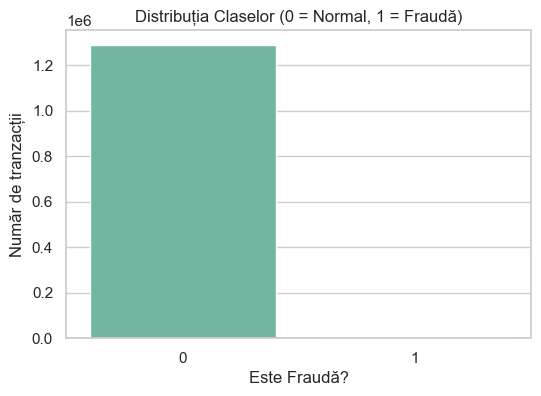

In [3]:
# Vizualizăm distribuția claselor (0 = normal, 1 = fraudă)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_synth, x='is_fraud', hue='is_fraud', palette='Set2', legend=False)
plt.title('Distribuția Claselor (0 = Normal, 1 = Fraudă)')
plt.xlabel('Este Fraudă?')
plt.ylabel('Număr de tranzacții')

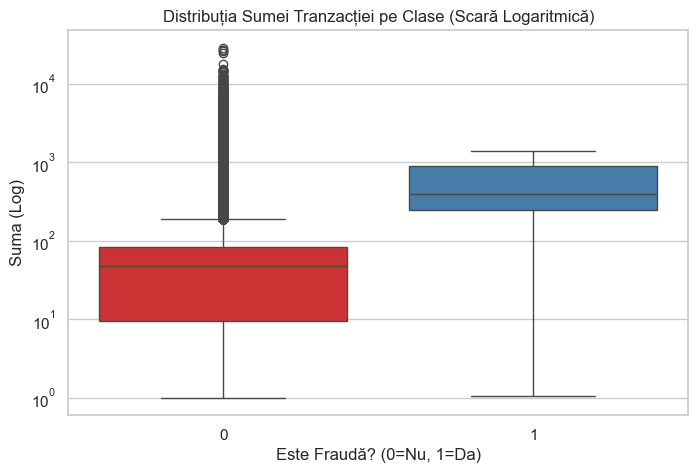

In [4]:
plt.figure(figsize=(8, 5))

# Folosim scară logaritmică pentru axa Y deoarece sumele pot fi extreme (outliers)
sns.boxplot(data=df_synth, x='is_fraud', y='amt', hue='is_fraud', palette='Set1', legend=False)
plt.yscale('log')
plt.title('Distribuția Sumei Tranzacției pe Clase (Scară Logaritmică)')
plt.xlabel('Este Fraudă? (0=Nu, 1=Da)')
plt.ylabel('Suma (Log)')
plt.show()

## 2. Fraud Distribution by Category
Identifying high-risk transaction types

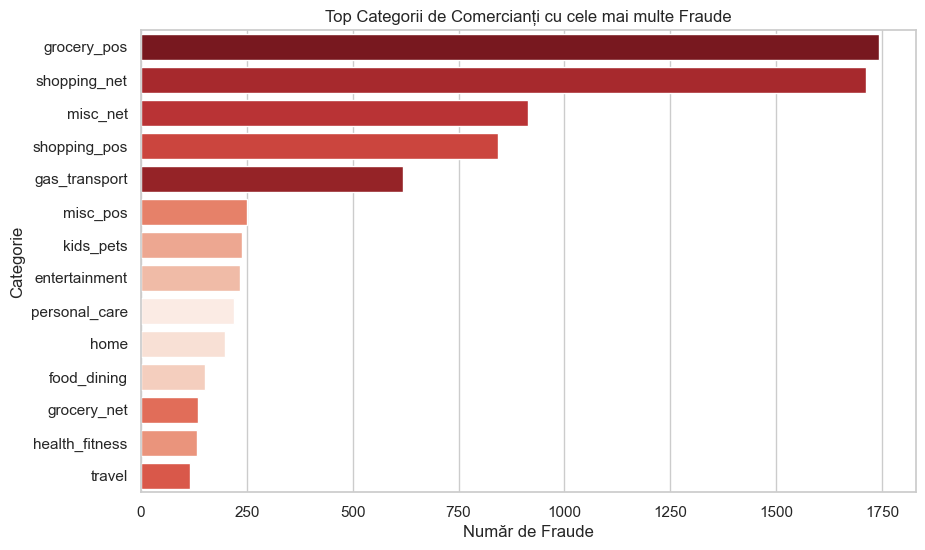

In [5]:
plt.figure(figsize=(10, 6))

# Filtrăm doar fraudele și numărăm categoriile
fraude_synth = df_synth[df_synth['is_fraud'] == 1]
sns.countplot(data=fraude_synth, y='category', hue='category', order=fraude_synth['category'].value_counts().index, palette='Reds_r', legend=False)
plt.title('Top Categorii de Comercianți cu cele mai multe Fraude')
plt.xlabel('Număr de Fraude')
plt.ylabel('Categorie')
plt.show()

## 3. Amount Distribution Analysis
Comparing transaction amounts for legitimate vs. fraudulent activities

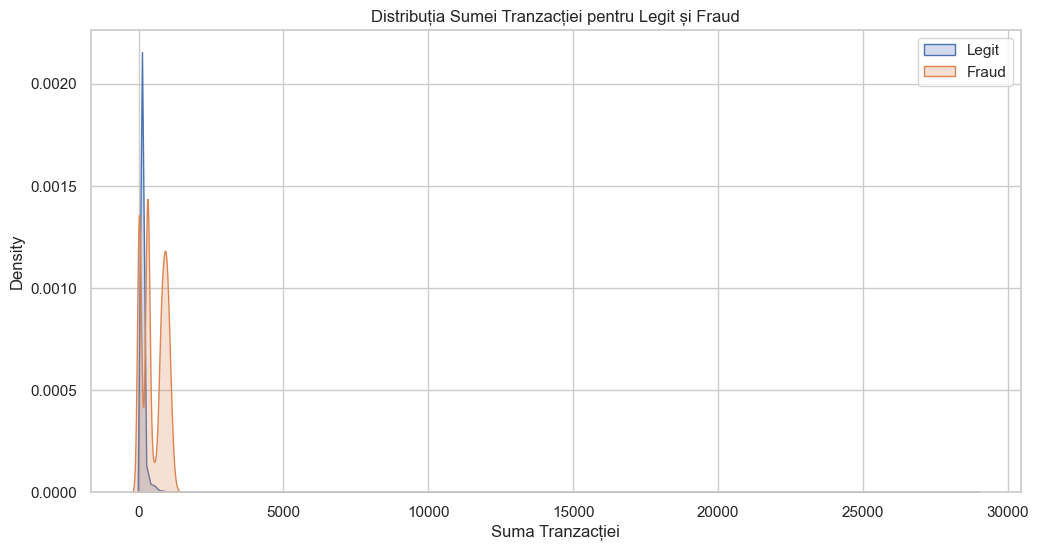

In [6]:
plt.figure(figsize=(12, 6))
sns.kdeplot(df_synth[df_synth['is_fraud'] == 0]['amt'], label='Legit', fill=True)
sns.kdeplot(df_synth[df_synth['is_fraud'] == 1]['amt'], label='Fraud', fill=True)
plt.title('Distribuția Sumei Tranzacției pentru Legit și Fraud')
plt.xlabel('Suma Tranzacției')
plt.legend()
plt.show()

## 4. Hourly Fraud Patterns
Investigating if fraud occurs more frequently at specific times of the day

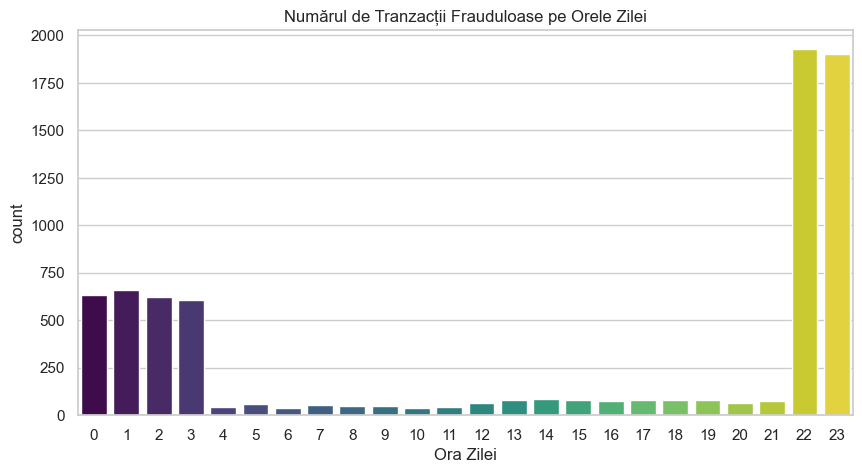

In [7]:
df_synth['hour'] = pd.to_datetime(df_synth['trans_date_trans_time']).dt.hour

plt.figure(figsize=(10, 5))
sns.countplot(data=df_synth[df_synth['is_fraud'] == 1], x='hour', hue='hour', palette='viridis', legend=False)
plt.title('Numărul de Tranzacții Frauduloase pe Orele Zilei')
plt.xlabel('Ora Zilei')
plt.show()

## 5. Demographic Analysis: Age of Victims
We aim to determine whether certain age groups are more likely to be targets of fraud. We will calculate age based on the `dob` (Date of Birth) column.

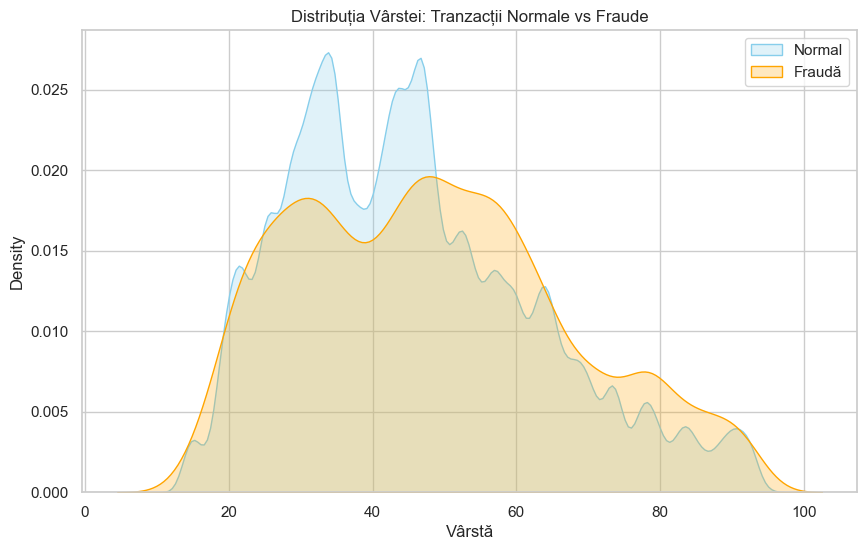

In [9]:


# Calculăm vârsta în momentul tranzacției
df_synth['dob'] = pd.to_datetime(df_synth['dob'])
df_synth['trans_date_trans_time'] = pd.to_datetime(df_synth['trans_date_trans_time'])
df_synth['age'] = (df_synth['trans_date_trans_time'] - df_synth['dob']).dt.days // 365

plt.figure(figsize=(10, 6))
sns.kdeplot(df_synth[df_synth['is_fraud'] == 0]['age'], label='Normal', fill=True, color='skyblue')
sns.kdeplot(df_synth[df_synth['is_fraud'] == 1]['age'], label='Fraudă', fill=True, color='orange')
plt.title('Distribuția Vârstei: Tranzacții Normale vs Fraude')
plt.xlabel('Vârstă')
plt.legend()
plt.show()

## 6.Correlation Between Amount and Category (Value Impact)
Are there categories where frauds are consistently high in value? We analyze the average fraud amount per category.

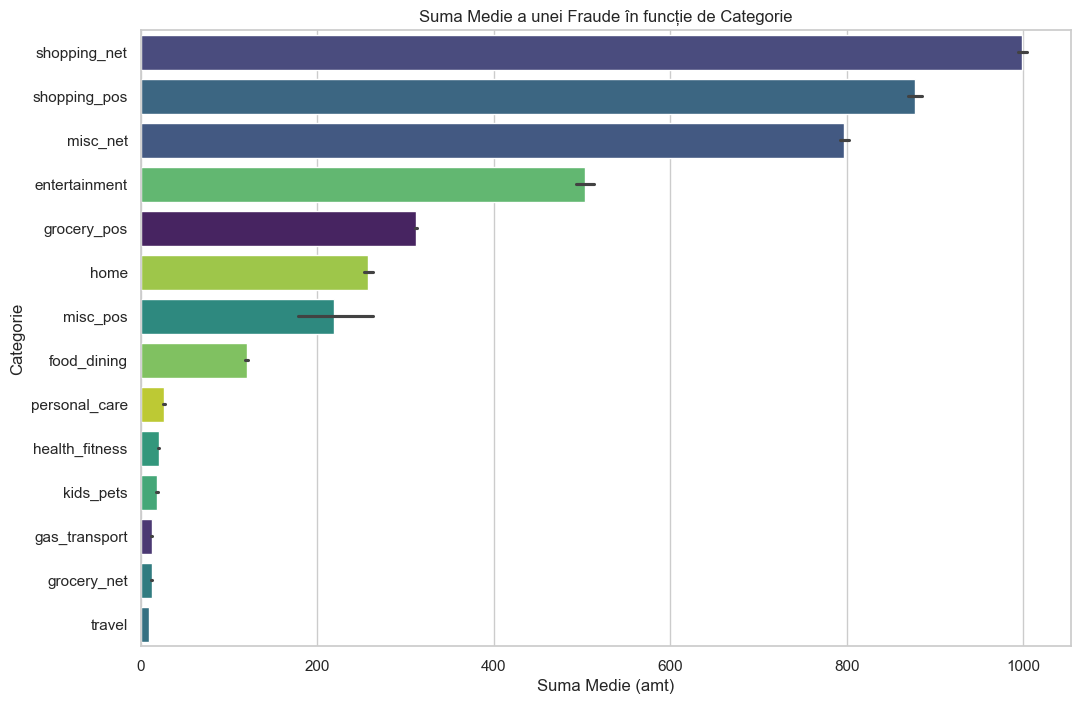

In [10]:
plt.figure(figsize=(12, 8))
# Analizăm doar tranzacțiile frauduloase
fraud_only = df_synth[df_synth['is_fraud'] == 1]

# Calculăm media sumei per categorie
order_by_amt = fraud_only.groupby('category')['amt'].mean().sort_values(ascending=False).index

sns.barplot(data=fraud_only, x='amt', y='category', order=order_by_amt, hue='category', palette='viridis', legend=False)
plt.title('Suma Medie a unei Fraude în funcție de Categorie')
plt.xlabel('Suma Medie (amt)')
plt.ylabel('Categorie')
plt.show()

## 7.Geographical Analysis (Top States)
We identify the geographical areas (states) that record the highest number of fraud incidents in this dataset.

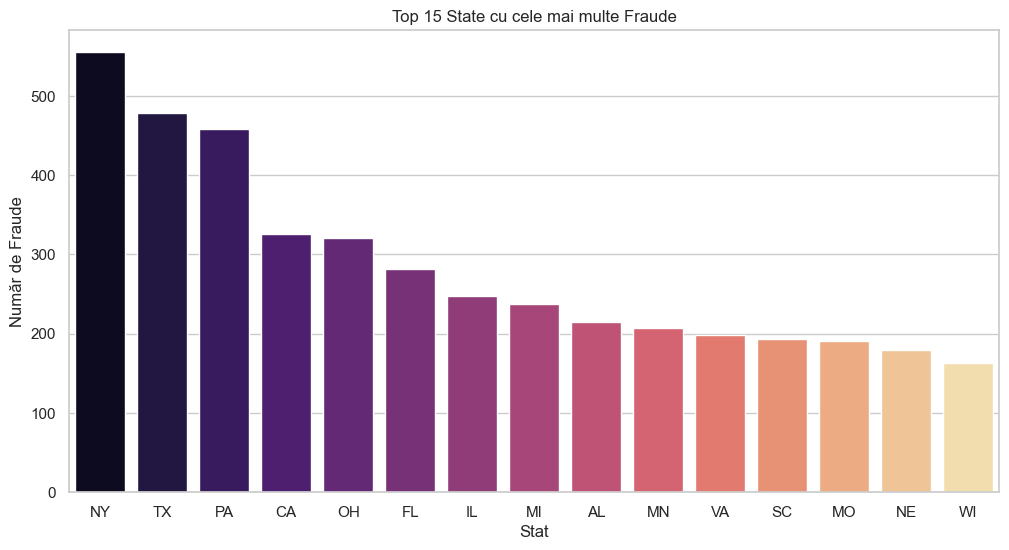

In [12]:
plt.figure(figsize=(12, 6))
state_fraud = df_synth[df_synth['is_fraud'] == 1]['state'].value_counts().head(15)
sns.barplot(x=state_fraud.index, y=state_fraud.values, hue=state_fraud.index, palette='magma', legend=False)
plt.title('Top 15 State cu cele mai multe Fraude')
plt.xlabel('Stat')
plt.ylabel('Număr de Fraude')
plt.show()